## IMPORT LIBRARIES

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

## LOAD DATASET

In [8]:
df = pd.read_csv(r"D:\Neha Final Year Project\BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## TARGET VARIABLE CREATION AND DATA CLEANING

In [9]:
df['Churn'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

df = df.drop(columns=[
    'Attrition_Flag',
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

## FEATURE ENGINEERING

In [10]:
df['Avg_Transaction_Value'] = df['Total_Trans_Amt'] / (df['Total_Trans_Ct'] + 1)
df['Engagement_Score'] = (
    df['Total_Relationship_Count'] +
    df['Contacts_Count_12_mon'] -
    df['Months_Inactive_12_mon']
)

## DEFINE FEATURES AND PEPROCESSING

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

categorical_cols = [
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

## DATA SPLIT

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## EXPLORATORY DATA ANALYSIS (EDA)

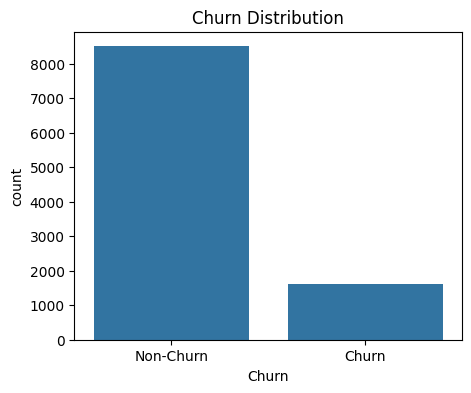

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xticks([0,1], ['Non-Churn', 'Churn'])
plt.show()

## BASELINE MODEL COMPARISON (WITHOUT SMOTE)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "SVM": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    
    "Naive Bayes": GaussianNB(),
    
    "KNN": KNeighborsClassifier(n_neighbors=7),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}
baseline_results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    baseline_results[name] = {
        "Accuracy Before SMOTE": accuracy_score(y_test, preds),
        "Recall Before SMOTE": recall_score(y_test, preds)
    }

pd.DataFrame(baseline_results).T

,Accuracy Before SMOTE,Recall Before SMOTE
Logistic Regression,0.902764,0.541538
Decision Tree,0.940770,0.769231
Random Forest,0.963475,0.809231
SVM,0.839585,0.000000
Naive Bayes,0.891905,0.556923
KNN,0.892892,0.556923
Gradient Boosting,0.964462,0.815385
XGBoost,0.968904,0.858462


## APPLY SMOTE & RE-EVALUATE MODELS

In [15]:
smote_results = {}

for name, model in models.items():
    
    pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    smote_results[name] = {
        "Accuracy After SMOTE": accuracy_score(y_test, preds),
        "Recall After SMOTE": recall_score(y_test, preds)
    }

pd.DataFrame(smote_results).T

,Accuracy After SMOTE,Recall After SMOTE
Logistic Regression,0.853406,0.809231
Decision Tree,0.925469,0.843077
Random Forest,0.950148,0.800000
SVM,0.719645,0.726154
Naive Bayes,0.741856,0.756923
KNN,0.841066,0.809231
Gradient Boosting,0.961994,0.846154
XGBoost,0.969398,0.892308


In [16]:
comparison = pd.concat([
    pd.DataFrame(baseline_results).T,
    pd.DataFrame(smote_results).T
], axis=1)

comparison

,Accuracy Before SMOTE,Recall Before SMOTE,Accuracy After SMOTE,Recall After SMOTE
Logistic Regression,0.902764,0.541538,0.853406,0.809231
Decision Tree,0.940770,0.769231,0.925469,0.843077
Random Forest,0.963475,0.809231,0.950148,0.800000
SVM,0.839585,0.000000,0.719645,0.726154
Naive Bayes,0.891905,0.556923,0.741856,0.756923
KNN,0.892892,0.556923,0.841066,0.809231
Gradient Boosting,0.964462,0.815385,0.961994,0.846154
XGBoost,0.968904,0.858462,0.969398,0.892308


## PERFORMANCE COMPARISON VISUALIZATION

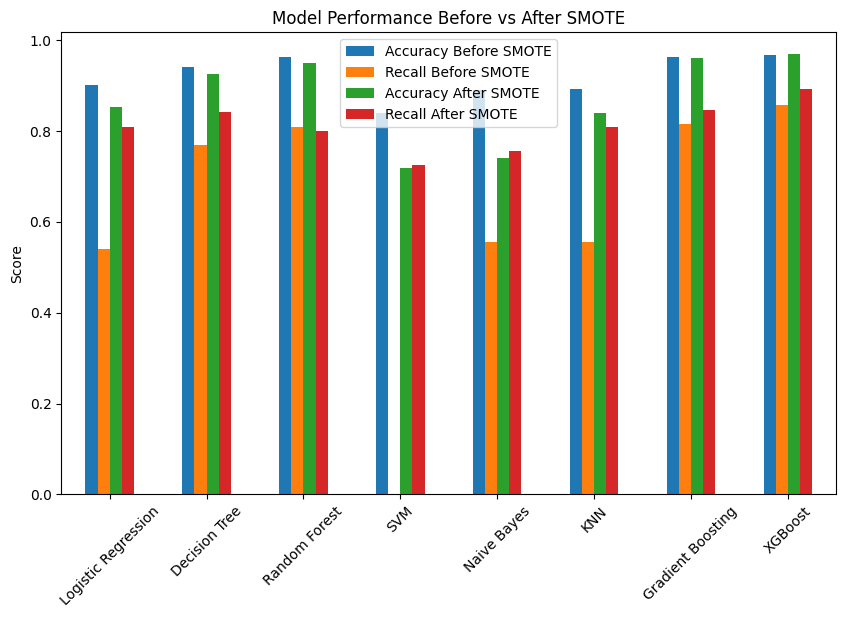

In [17]:
comparison.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Before vs After SMOTE")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

## FINAL MODEL SELECTION (XGBOOST)

In [18]:
final_pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## CROSS-VALIDATION

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

print("CV Recall Scores:", cv_scores)
print("Mean CV Recall:", cv_scores.mean())

CV Recall Scores: [0.88505747 0.89615385 0.90384615 0.92692308 0.88122605]
Mean CV Recall: 0.8986413203654584


## FINAL MODEL EVALUATION

In [20]:
probs = final_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.40
y_pred = (probs >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, probs))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9689042448173741
Recall: 0.8892307692307693
Precision: 0.9145569620253164
F1: 0.9017160686427457
AUC: 0.9922706100483878

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.91      0.89      0.90       325

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



## CONFUSION MATRIX

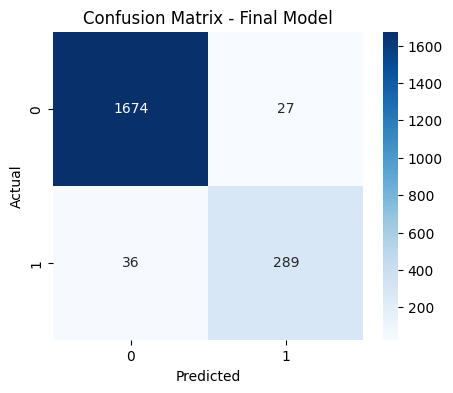

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

## ROC CURVE ANALYSIS

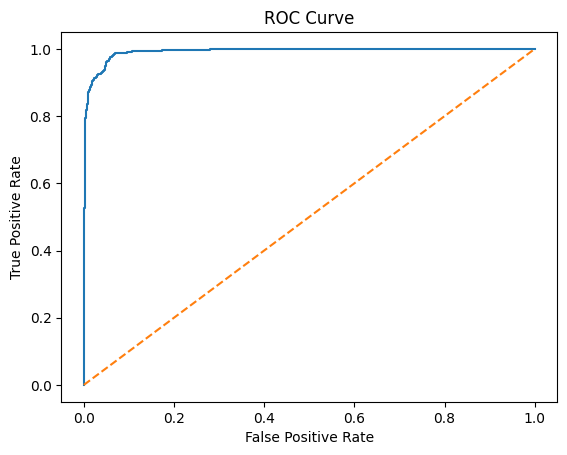

In [22]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## PRECISION-RECALL CURVE

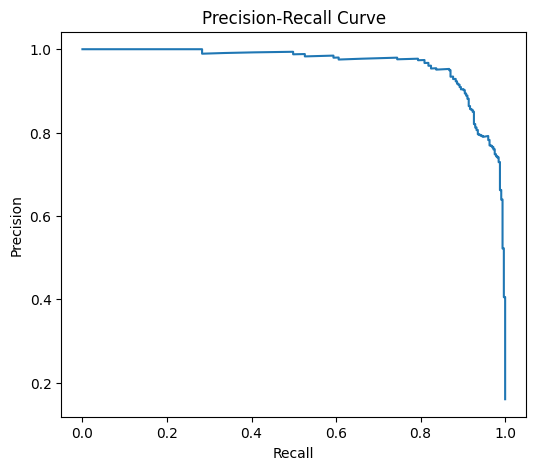

In [23]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## RISK SCORING FRAMEWORK

In [24]:
risk_df = X_test.copy()
risk_df['Churn_Probability'] = probs
risk_df['Actual_Churn'] = y_test.values

In [25]:
# Risk Segmentation Function

def segment_risk(p):
    if p >= 0.70:
        return "High Risk"
    elif p >= 0.30:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df['Risk_Group'] = risk_df['Churn_Probability'].apply(segment_risk)

risk_df[['Churn_Probability','Risk_Group']].head()

,Churn_Probability,Risk_Group
2919,0.000529,Low Risk
9301,0.000929,Low Risk
2936,0.246921,Low Risk
8134,0.000142,Low Risk
5902,0.000090,Low Risk


## VALUE AT RISK (VaR) ANALYSIS

In [26]:
risk_df['VaR'] = risk_df['Churn_Probability'] * risk_df['Credit_Limit']
risk_df.sort_values(by='VaR', ascending=False).head(10)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Transaction_Value,Engagement_Score,Churn_Probability,Actual_Churn,Risk_Group,VaR
9474,50,M,1,Graduate,Single,$80K - $120K,Silver,43,6,3,...,9045,72,1.000,0.013,123.904110,6,0.999264,1,High Risk,34490.586001
10112,33,M,2,College,Married,$120K +,Gold,20,2,1,...,9338,73,0.622,0.000,126.189189,5,0.998126,1,High Risk,34451.328337
3049,48,M,3,Post-Graduate,Unknown,$120K +,Blue,35,2,2,...,1632,44,0.333,0.000,36.266667,6,0.997977,1,High Risk,34446.189167
9552,39,M,2,Unknown,Married,$120K +,Blue,36,6,3,...,7866,63,0.750,0.073,122.906250,6,0.997129,1,High Risk,34416.893017
8767,41,M,2,Graduate,Single,$60K - $80K,Gold,36,2,3,...,4822,57,0.295,0.020,83.137931,2,0.995522,1,High Risk,34361.446349
9655,50,M,2,Graduate,Single,$80K - $120K,Silver,40,3,4,...,7661,79,1.079,0.000,95.762500,5,0.992013,1,High Risk,34240.326107
4487,46,F,3,High School,Single,Unknown,Silver,36,4,2,...,1987,46,0.586,0.004,42.276596,5,0.987120,1,High Risk,34071.426806
4406,48,M,4,Uneducated,Single,$80K - $120K,Silver,43,2,3,...,1626,28,0.400,0.000,56.068966,3,0.980520,1,High Risk,33843.638952
9223,56,M,1,Uneducated,Married,$80K - $120K,Blue,36,6,2,...,7661,61,0.525,0.000,123.564516,5,0.974267,1,High Risk,32998.429547
9968,51,F,1,Graduate,Married,Unknown,Silver,44,4,2,...,10156,72,0.946,0.073,139.123288,6,0.994460,1,High Risk,32821.157401


## CUSTOMER PRIORITIZATION

In [27]:
# Rank customers based on financial risk
risk_df['Priority_Rank'] = risk_df['VaR'].rank(
    ascending=False,
    method='dense'
)

risk_df.sort_values('Priority_Rank').head(10)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Transaction_Value,Engagement_Score,Churn_Probability,Actual_Churn,Risk_Group,VaR,Priority_Rank
9474,50,M,1,Graduate,Single,$80K - $120K,Silver,43,6,3,...,72,1.000,0.013,123.904110,6,0.999264,1,High Risk,34490.586001,1.0
10112,33,M,2,College,Married,$120K +,Gold,20,2,1,...,73,0.622,0.000,126.189189,5,0.998126,1,High Risk,34451.328337,2.0
3049,48,M,3,Post-Graduate,Unknown,$120K +,Blue,35,2,2,...,44,0.333,0.000,36.266667,6,0.997977,1,High Risk,34446.189167,3.0
9552,39,M,2,Unknown,Married,$120K +,Blue,36,6,3,...,63,0.750,0.073,122.906250,6,0.997129,1,High Risk,34416.893017,4.0
8767,41,M,2,Graduate,Single,$60K - $80K,Gold,36,2,3,...,57,0.295,0.020,83.137931,2,0.995522,1,High Risk,34361.446349,5.0
9655,50,M,2,Graduate,Single,$80K - $120K,Silver,40,3,4,...,79,1.079,0.000,95.762500,5,0.992013,1,High Risk,34240.326107,6.0
4487,46,F,3,High School,Single,Unknown,Silver,36,4,2,...,46,0.586,0.004,42.276596,5,0.987120,1,High Risk,34071.426806,7.0
4406,48,M,4,Uneducated,Single,$80K - $120K,Silver,43,2,3,...,28,0.400,0.000,56.068966,3,0.980520,1,High Risk,33843.638952,8.0
9223,56,M,1,Uneducated,Married,$80K - $120K,Blue,36,6,2,...,61,0.525,0.000,123.564516,5,0.974267,1,High Risk,32998.429547,9.0
9968,51,F,1,Graduate,Married,Unknown,Silver,44,4,2,...,72,0.946,0.073,139.123288,6,0.994460,1,High Risk,32821.157401,10.0


In [52]:
top_priority = risk_df.sort_values(
    by='VaR',
    ascending=False
).head(10)

top_priority[
    ['Churn_Probability','Risk_Group','VaR','Priority_Rank']
]

,Churn_Probability,Risk_Group,VaR,Priority_Rank
9474,0.999264,High Risk,34490.586001,1.0
10112,0.998126,High Risk,34451.328337,2.0
3049,0.997977,High Risk,34446.189167,3.0
9552,0.997129,High Risk,34416.893017,4.0
8767,0.995522,High Risk,34361.446349,5.0
9655,0.992013,High Risk,34240.326107,6.0
4487,0.987120,High Risk,34071.426806,7.0
4406,0.980520,High Risk,33843.638952,8.0
9223,0.974267,High Risk,32998.429547,9.0
9968,0.994460,High Risk,32821.157401,10.0


## FEATURE IMPORTANCE (EXPLAINABILITY)

In [28]:
# Get feature names from preprocessor
feature_names = final_pipeline.named_steps['preprocess'].get_feature_names_out()
feature_names = pd.Series(feature_names)
feature_names = feature_names.str.replace("remainder__", "", regex=False)
feature_names = feature_names.str.replace("cat__", "", regex=False)

# Get trained model
model = final_pipeline.named_steps['model']

# Get importance values
importances = model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Show top 15 features
feature_importance_df.head(15)

,Feature,Importance
29,Total_Trans_Ct,0.219026
21,Total_Relationship_Count,0.072036
25,Total_Revolving_Bal,0.069451
7,Marital_Status_Married,0.068996
22,Months_Inactive_12_mon,0.055062
16,Card_Category_Platinum,0.052003
0,Gender_M,0.051093
32,Avg_Transaction_Value,0.050537
28,Total_Trans_Amt,0.047030
23,Contacts_Count_12_mon,0.035774


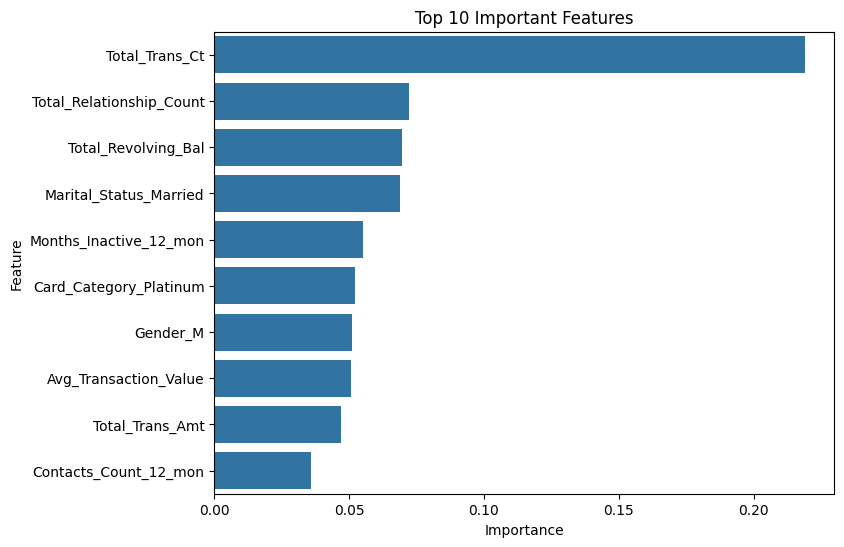

In [29]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

## CORRELATION ANALYSIS

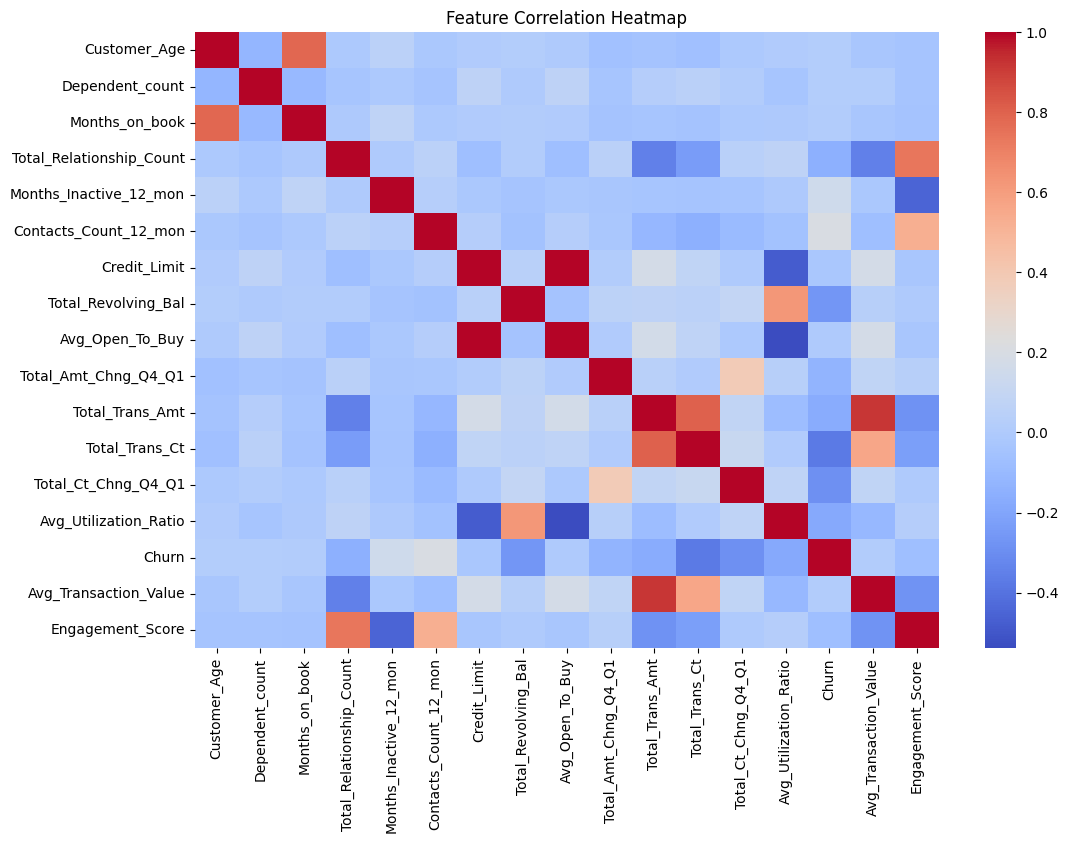

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## DECISION SUPPORT MODULE

In [31]:
def recommended_action(row):
    if row['Risk_Group'] == "High Risk" and row['VaR'] > 5000:
        return "Immediate retention call + premium incentive"
    
    elif row['Risk_Group'] == "High Risk":
        return "Retention email campaign"

    elif row['Risk_Group'] == "Medium Risk" and row['VaR'] > 5000:
        return "Targeted engagement campaign"

    elif row['Risk_Group'] == "Medium Risk":
        return "Monitor engagement"

    else:
        return "No immediate action"

# Apply function row-wise
risk_df['Recommended_Action'] = risk_df.apply(recommended_action, axis=1)

# Check output
risk_df[['Churn_Probability', 'Risk_Group', 'VaR', 'Recommended_Action']].head()


,Churn_Probability,Risk_Group,VaR,Recommended_Action
2919,0.000529,Low Risk,1.706127,No immediate action
9301,0.000929,Low Risk,10.646442,No immediate action
2936,0.246921,Low Risk,414.086097,No immediate action
8134,0.000142,Low Risk,0.204721,No immediate action
5902,0.000090,Low Risk,0.136471,No immediate action


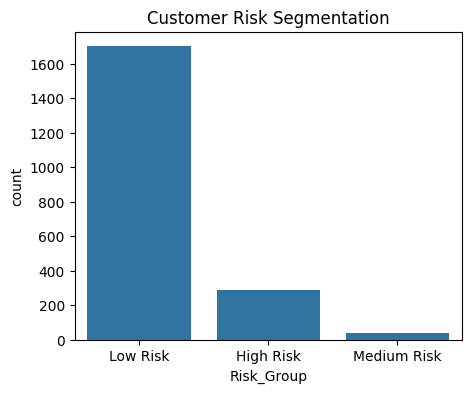

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(x='Risk_Group', data=risk_df)
plt.title("Customer Risk Segmentation")
plt.show()

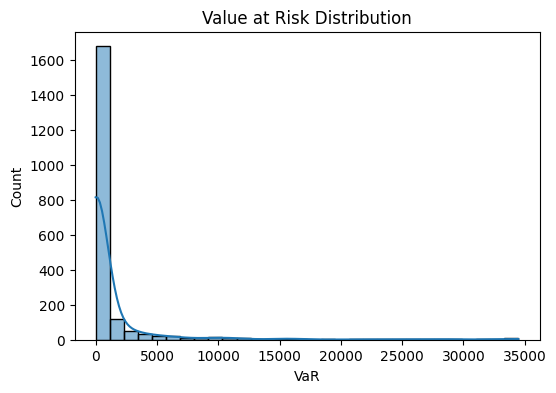

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(risk_df['VaR'], bins=30, kde=True)
plt.title("Value at Risk Distribution")
plt.show()

## WHAT-IF SIMULATION MODULE

In [34]:
def what_if_simulation(customer_row, feature, new_value=None, change_value=None):
    
    modified = customer_row.copy()
    
    # Option 1: Direct assign
    if new_value is not None:
        modified[feature] = new_value
    
    # Option 2: Increment
    elif change_value is not None:
        modified[feature] += change_value
    
    else:
        raise ValueError("Provide either new_value or change_value")
    
    # Convert to DataFrame
    modified_df = pd.DataFrame([modified])
    
    # Use full pipeline (preprocessing + model)
    new_prob = final_pipeline.predict_proba(modified_df)[:, 1][0]
    
    return new_prob

In [35]:
customer = risk_df.iloc[2]

original_prob = customer['Churn_Probability']
print("Original Probability:", round(original_prob, 3))

Original Probability: 0.247


In [36]:
prob_relationship = what_if_simulation(
    X_test.loc[customer.name],
    feature='Total_Relationship_Count',
    change_value=1
)

print("After Relationship Increase:", round(prob_relationship, 3))

After Relationship Increase: 0.23


In [37]:
prob_inactive = what_if_simulation(
    X_test.loc[customer.name],
    feature='Months_Inactive_12_mon',
    change_value=-2
)

print("After Reduced Inactivity:", round(prob_inactive, 3))

After Reduced Inactivity: 0.293


In [38]:
prob_transaction = what_if_simulation(
    X_test.loc[customer.name],
    feature='Total_Trans_Amt',
    change_value=2000
)

print("After Increased Transactions:", round(prob_transaction, 3))

After Increased Transactions: 0.094


In [39]:
prob_card_upgrade = what_if_simulation(
    X_test.loc[customer.name],
    feature='Card_Category',
    new_value='Platinum'
)

print("After Card Upgrade:", round(prob_card_upgrade, 3))

After Card Upgrade: 0.26


In [40]:
high_risk_customers = risk_df[
    risk_df['Risk_Group'] == "High Risk"
].head(5)

for index, customer in high_risk_customers.iterrows():
    
    print("\nCustomer Index:", index)
    
    original_prob = customer['Churn_Probability']
    print("Original Probability:", round(original_prob, 3))
    
    prob_relationship = what_if_simulation(
        X_test.loc[index],
        feature='Total_Relationship_Count',
        change_value=1
    )
    
    prob_inactive = what_if_simulation(
        X_test.loc[index],
        feature='Months_Inactive_12_mon',
        change_value=-2
    )
    
    print("After Relationship Increase:", round(prob_relationship, 3))
    print("After Reduced Inactivity:", round(prob_inactive, 3))


Customer Index: 9552
Original Probability: 0.997
After Relationship Increase: 0.997
After Reduced Inactivity: 0.951

Customer Index: 9661
Original Probability: 0.977
After Relationship Increase: 0.993
After Reduced Inactivity: 0.93

Customer Index: 8574
Original Probability: 0.999
After Relationship Increase: 0.999
After Reduced Inactivity: 0.999

Customer Index: 8470
Original Probability: 0.922
After Relationship Increase: 0.493
After Reduced Inactivity: 0.724

Customer Index: 8999
Original Probability: 1.0
After Relationship Increase: 0.999
After Reduced Inactivity: 0.999
